# BurnoutLens
## AI-Based Burnout Risk Prediction using Hybrid Machine Learning
### Student: Pratheen K
### Student: Rithish Kumar D
### Dataset: Sleep Health and Lifestyle Dataset

# 1. Import Required Libraries

In [2]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# 2. Load the Dataset

In [3]:
# Load the dataset

df = pd.read_csv("../data/Sleep_health_and_lifestyle_dataset.csv")

# 3. Data Understanding

In [4]:
# Display the first 5 rows

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [5]:
# Check the size of the dataset

print("Rows and Columns:", df.shape)

Rows and Columns: (374, 13)


In [6]:
# Display all column names

print(df.columns)

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')


In [7]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [8]:
# Display statistical summary of numerical columns

df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


# 4. Data Cleaning

In [9]:
# ==========================================
# Missing Values Analysis
# ==========================================

print("Missing Values in Each Column:\n")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

Total Missing Values: 219


In [10]:
# ==========================================
# Duplicate Records
# ==========================================

duplicates = df.duplicated().sum()

print("Total Duplicate Records:", duplicates)

Total Duplicate Records: 0


In [11]:
# ==========================================
# Unique Values in Each Column
# ==========================================

for column in df.columns:
    print(f"\n{column}")
    print("-"*40)
    print(df[column].unique())


Person ID
----------------------------------------
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234

In [12]:
# ==========================================
# Number of Unique Values
# ==========================================

print(df.nunique())

Person ID                  374
Gender                       2
Age                         31
Occupation                  11
Sleep Duration              27
Quality of Sleep             6
Physical Activity Level     16
Stress Level                 6
BMI Category                 4
Blood Pressure              25
Heart Rate                  19
Daily Steps                 20
Sleep Disorder               2
dtype: int64


In [13]:
# ==========================================
# Numerical and Categorical Features
# ==========================================

numerical_columns = df.select_dtypes(include=['int64','float64']).columns

categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Numerical Features
Index(['Person ID', 'Age', 'Sleep Duration', 'Quality of Sleep',
       'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps'],
      dtype='object')

Categorical Features
Index(['Gender', 'Occupation', 'BMI Category', 'Blood Pressure',
       'Sleep Disorder'],
      dtype='object')


In [14]:
# ==========================================
# Stress Level Distribution
# ==========================================

print(df["Stress Level"].value_counts().sort_index())

Stress Level
3    71
4    70
5    67
6    46
7    50
8    70
Name: count, dtype: int64


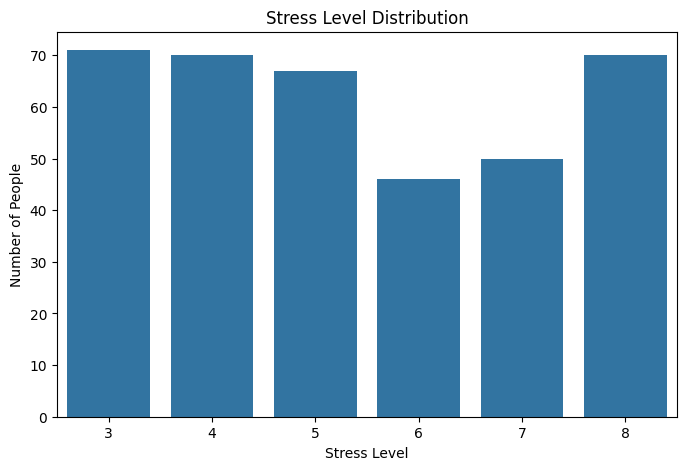

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x="Stress Level", data=df)

plt.title("Stress Level Distribution")

plt.xlabel("Stress Level")

plt.ylabel("Number of People")

plt.show()

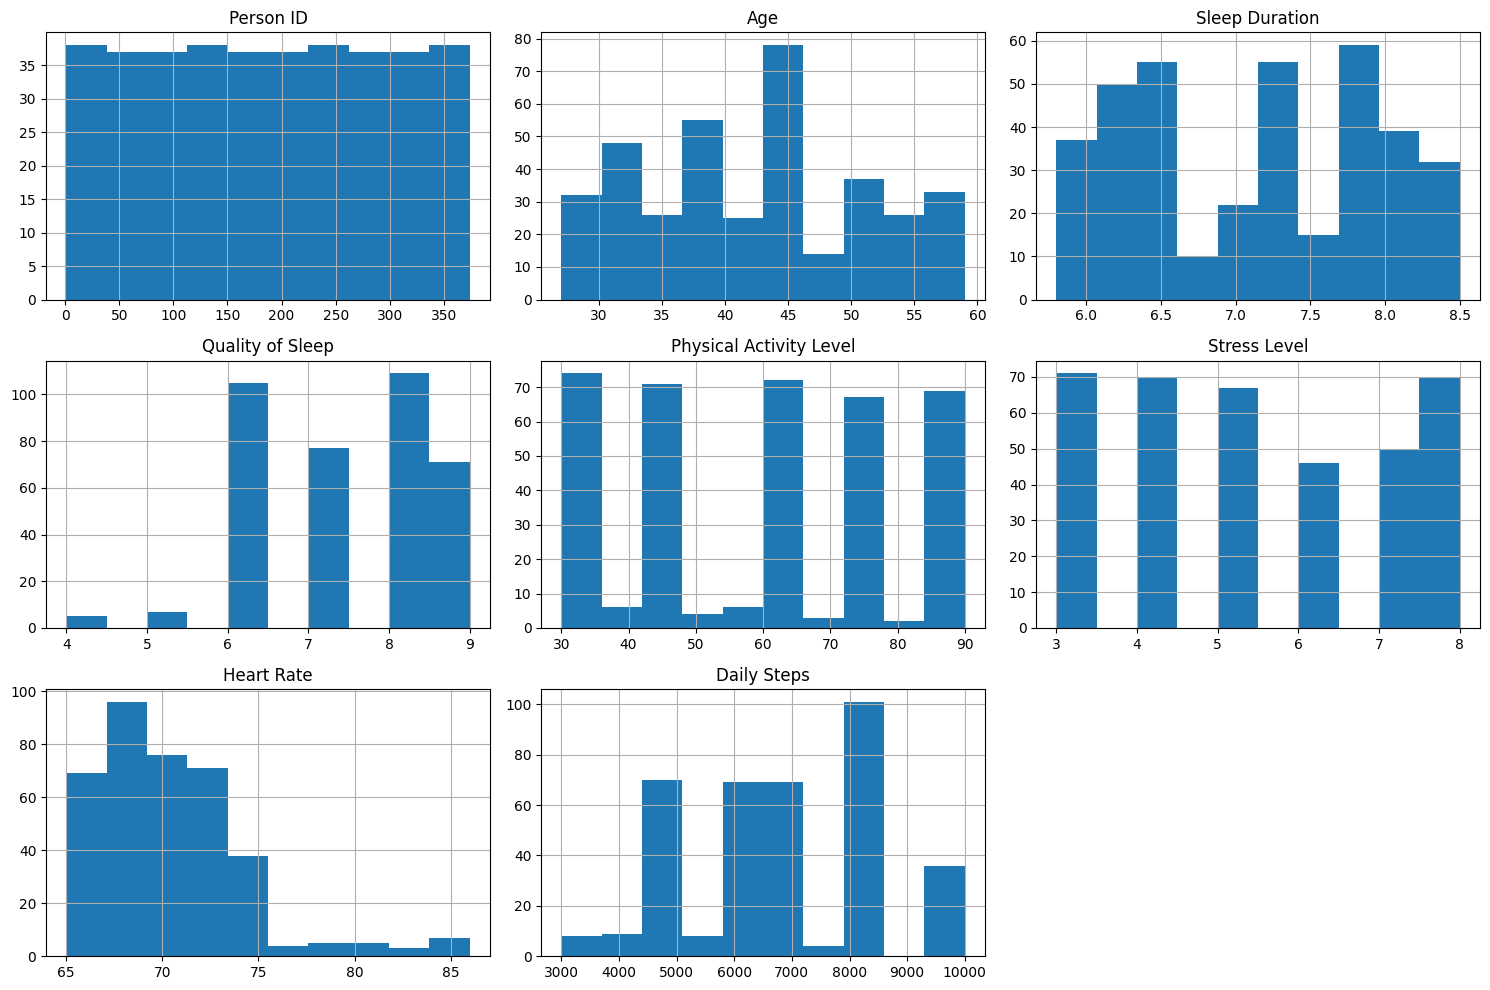

In [16]:
# ==========================================
# Histograms
# ==========================================

df.hist(figsize=(15,10))

plt.tight_layout()

plt.show()

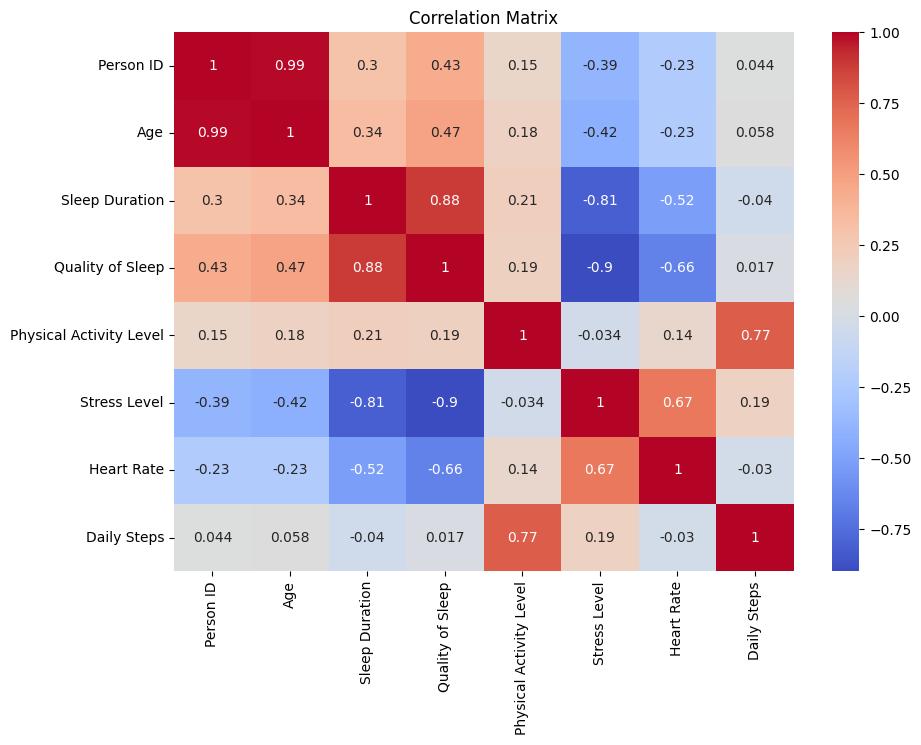

In [17]:
# ==========================================
# Correlation Matrix
# ==========================================

plt.figure(figsize=(10,7))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

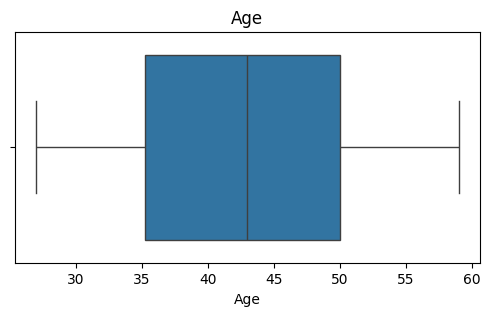

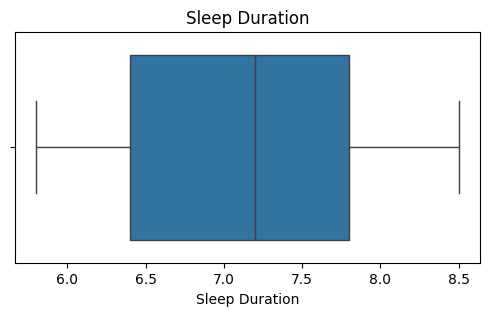

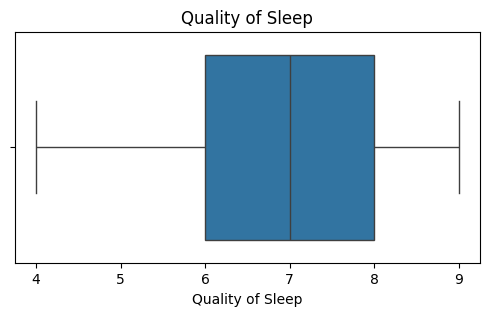

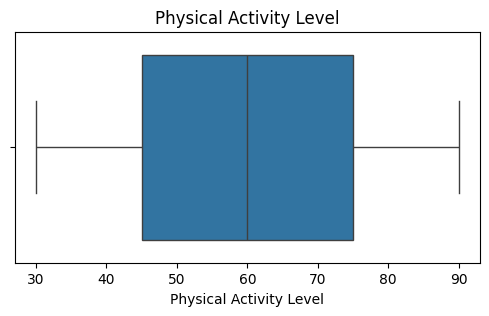

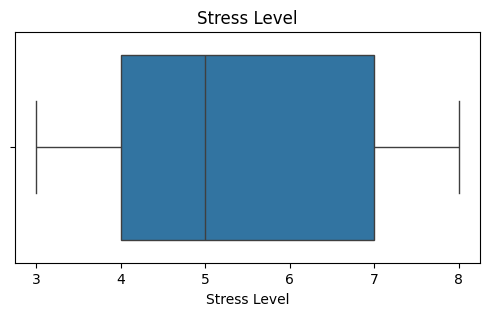

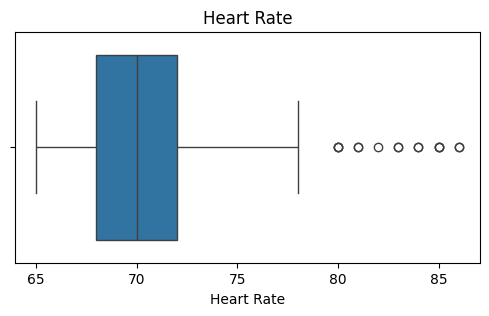

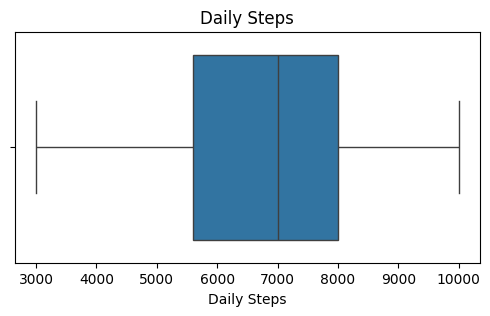

In [18]:
# ==========================================
# Boxplots
# ==========================================

numeric_columns = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

for column in numeric_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

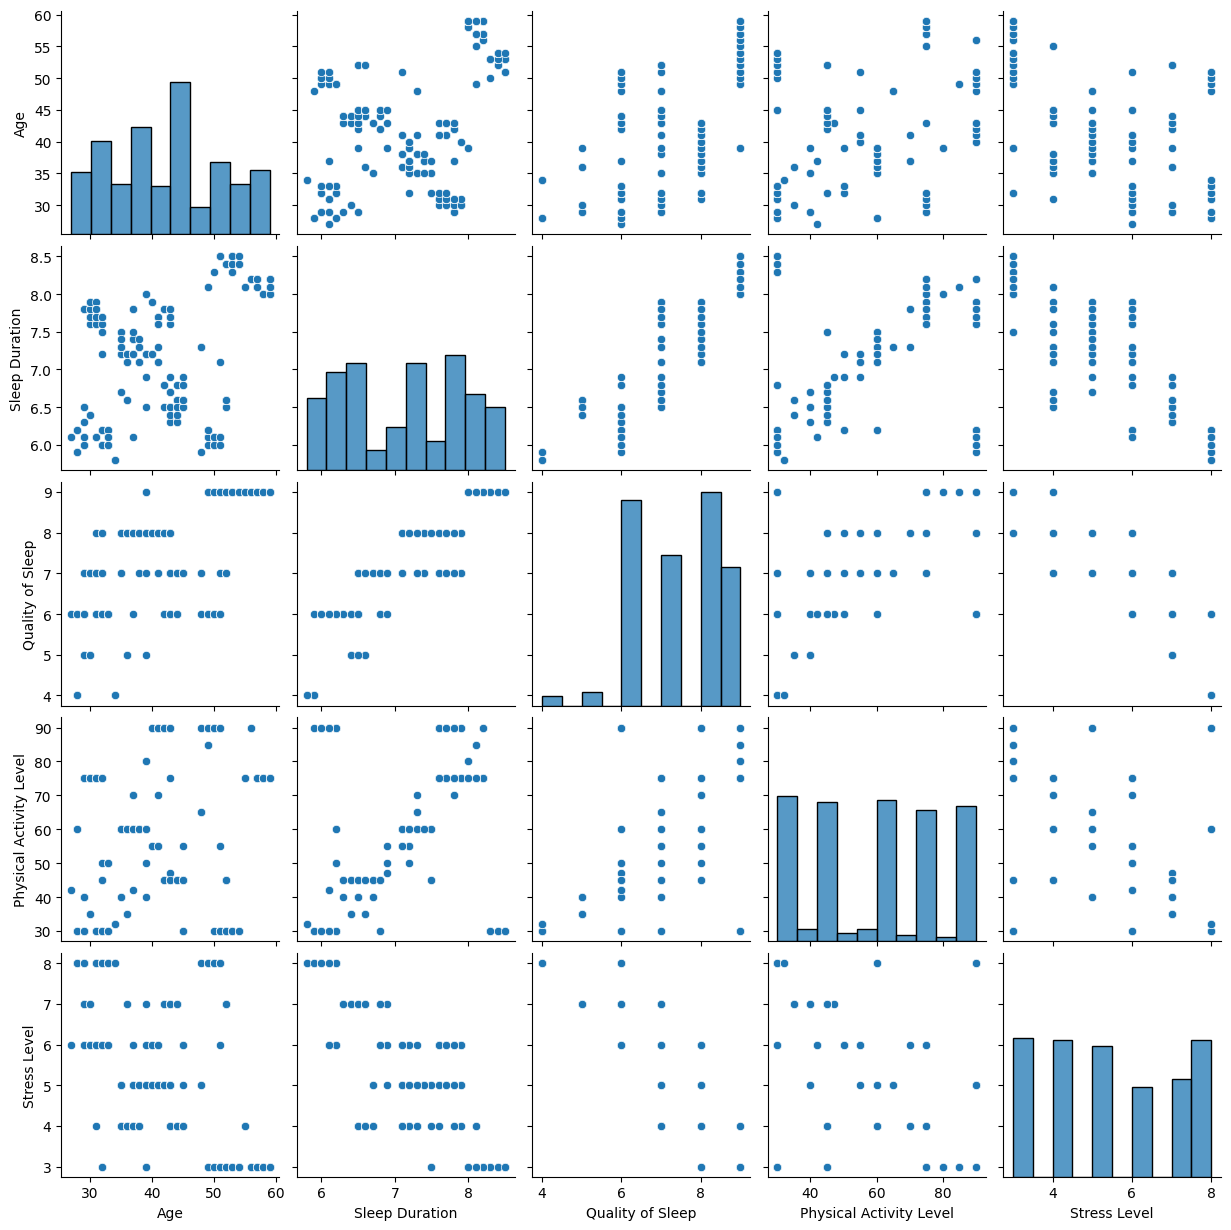

In [19]:
sns.pairplot(df[
[
"Age",
"Sleep Duration",
"Quality of Sleep",
"Physical Activity Level",
"Stress Level"
]])

plt.show()

In [20]:
# Create a copy of the dataset

data = df.copy()

print("Working copy created successfully!")

Working copy created successfully!


In [21]:
# Check missing values

data.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [22]:
# Remove Person ID

data.drop("Person ID", axis=1, inplace=True)

data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [23]:
# Fill missing sleep disorder values

data["Sleep Disorder"] = data["Sleep Disorder"].fillna("None")

In [24]:
data.isnull().sum()

Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64

In [25]:
# Split Blood Pressure

data[["Systolic BP", "Diastolic BP"]] = data["Blood Pressure"].str.split("/", expand=True)

data.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea,140,90


In [26]:
data["Systolic BP"] = data["Systolic BP"].astype(int)

data["Diastolic BP"] = data["Diastolic BP"].astype(int)

In [27]:
data["Systolic BP"] = data["Systolic BP"].astype(int)

data["Diastolic BP"] = data["Diastolic BP"].astype(int)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Blood Pressure           374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           374 non-null    object 
 12  Systolic BP              374 non-null    int64  
 13  Diastolic BP             374 non-null    int64  
dtypes: float64(1), int64(8), o

# 5. Feature Engineering
## 5.1 Creating the Burnout Risk Target Variable

In [29]:
# Create Burnout Risk from Stress Level

def classify_burnout(stress):
    if stress <= 4:
        return "Low"
    elif stress <= 6:
        return "Medium"
    else:
        return "High"

data["Burnout Risk"] = data["Stress Level"].apply(classify_burnout)

data[["Stress Level", "Burnout Risk"]].head(10)

,Stress Level,Burnout Risk
0,6,Medium
1,8,High
2,8,High
3,8,High
4,8,High
5,8,High
6,7,High
7,6,Medium
8,6,Medium
9,6,Medium


In [30]:
# Check class distribution

data["Burnout Risk"].value_counts()

Burnout Risk
Low       141
High      120
Medium    113
Name: count, dtype: int64

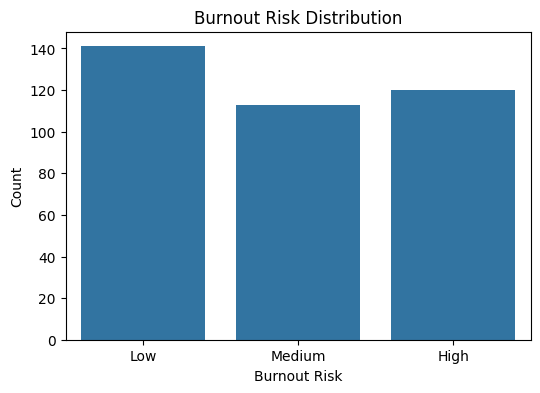

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Burnout Risk",
    data=data,
    order=["Low", "Medium", "High"]
)

plt.title("Burnout Risk Distribution")
plt.xlabel("Burnout Risk")
plt.ylabel("Count")

plt.show()

## 5.2 Lifestyle Score Calculation

In [32]:
def calculate_lifestyle_score(row):

    score = 0

    # Sleep Duration (Ideal: 7-9 hrs)
    if 7 <= row["Sleep Duration"] <= 9:
        score += 20
    elif 6 <= row["Sleep Duration"] < 7:
        score += 15
    else:
        score += 8

    # Quality of Sleep
    score += (row["Quality of Sleep"] / 9) * 20

    # Physical Activity
    score += (row["Physical Activity Level"] / 90) * 20

    # Daily Steps
    score += min(row["Daily Steps"] / 10000, 1) * 20

    # Heart Rate (Ideal: 60–75 BPM)
    if 60 <= row["Heart Rate"] <= 75:
        score += 20
    elif 76 <= row["Heart Rate"] <= 80:
        score += 15
    else:
        score += 8

    return round(score,2)


data["Lifestyle Score"] = data.apply(calculate_lifestyle_score, axis=1)

data[["Lifestyle Score"]].head()

,Lifestyle Score
0,61.07
1,81.67
2,81.67
3,37.56
4,37.56


In [33]:
data["Lifestyle Score"].describe()

count    374.000000
mean      80.303850
std       10.941214
min       37.560000
25%       72.560000
50%       85.110000
75%       88.330000
max      100.000000
Name: Lifestyle Score, dtype: float64

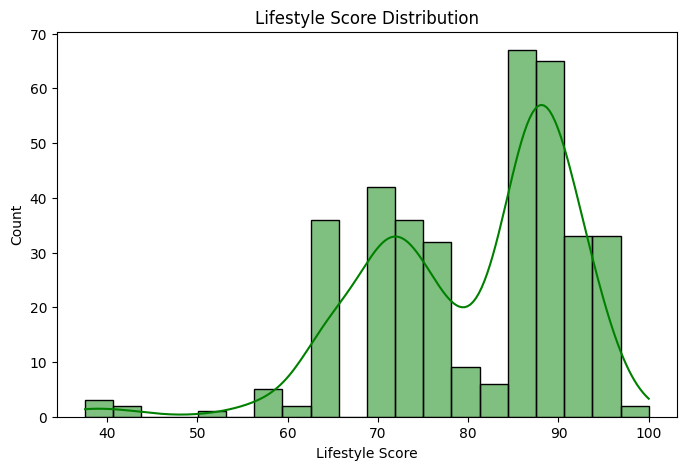

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    data["Lifestyle Score"],
    bins=20,
    kde=True,
    color="green"
)

plt.title("Lifestyle Score Distribution")

plt.show()

## 5.3 Lifestyle Category

In [35]:
def lifestyle_category(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Average"

    else:
        return "Poor"


data["Lifestyle Category"] = data["Lifestyle Score"].apply(lifestyle_category)

data[["Lifestyle Score","Lifestyle Category"]].head()

,Lifestyle Score,Lifestyle Category
0,61.07,Good
1,81.67,Excellent
2,81.67,Excellent
3,37.56,Poor
4,37.56,Poor


C:\Users\prath\AppData\Local\Temp\ipykernel_7360\3273303169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


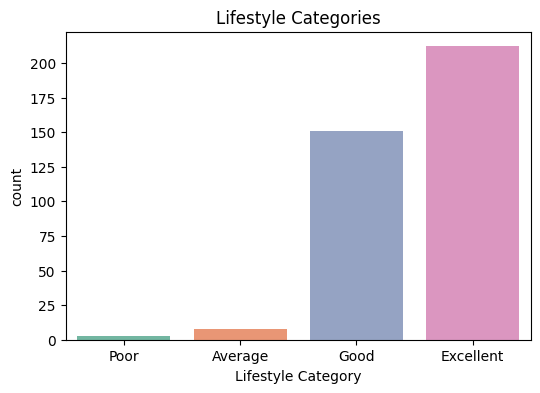

In [36]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Lifestyle Category",
    data=data,
    order=["Poor","Average","Good","Excellent"],
    palette="Set2"
)

plt.title("Lifestyle Categories")

plt.show()

## 5.4 Burnout Index

In [38]:
data["Burnout Index"] = (
    data["Stress Level"] * 10
    + (100 - data["Lifestyle Score"])
)

data[["Burnout Index"]].head()

,Burnout Index
0,98.93
1,98.33
2,98.33
3,142.44
4,142.44


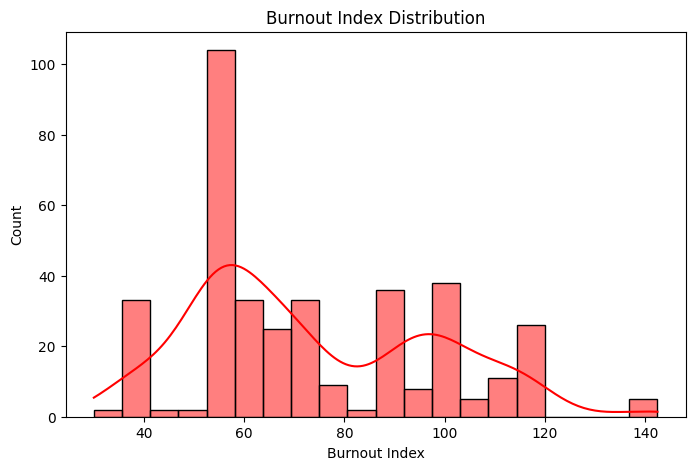

In [39]:
plt.figure(figsize=(8,5))

sns.histplot(
    data["Burnout Index"],
    bins=20,
    kde=True,
    color="red"
)

plt.title("Burnout Index Distribution")

plt.show()

# 6. Exploratory Data Analysis (EDA)

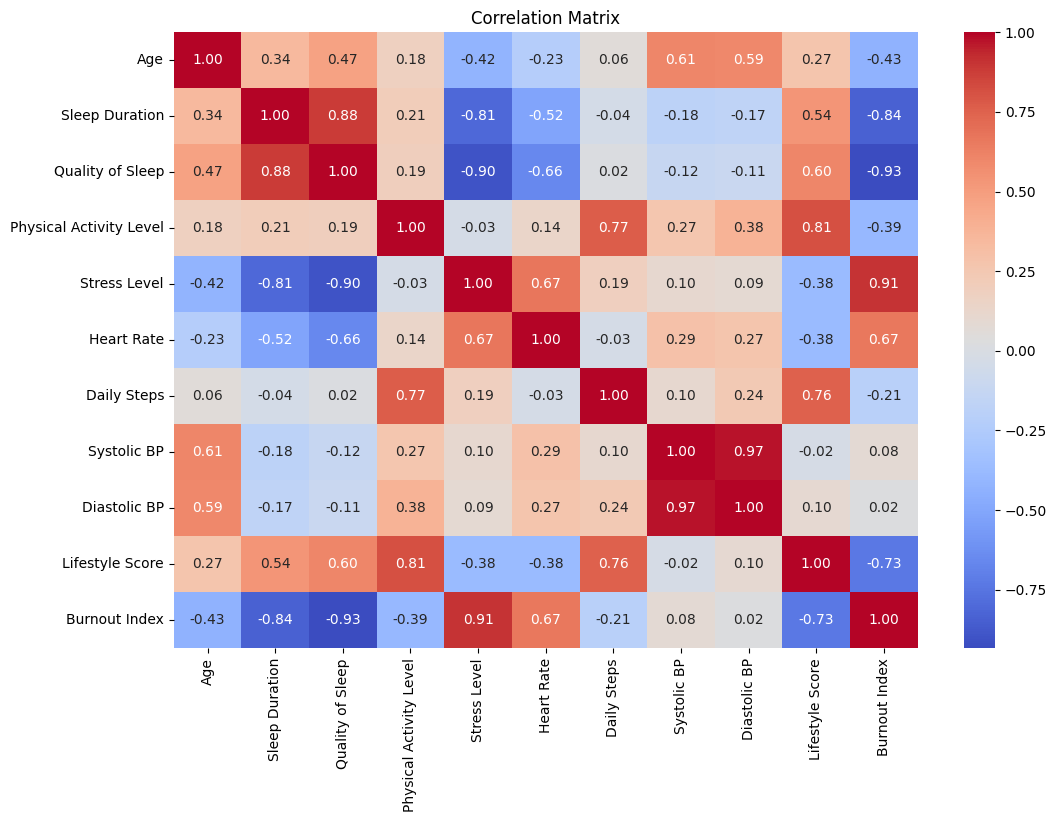

In [40]:
plt.figure(figsize=(12,8))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

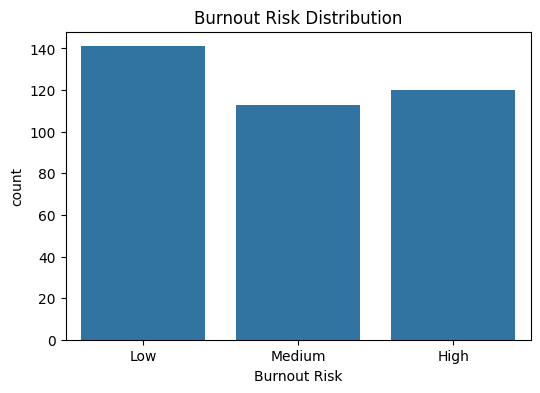

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Burnout Risk",
    data=data,
    order=["Low","Medium","High"]
)

plt.title("Burnout Risk Distribution")
plt.show()

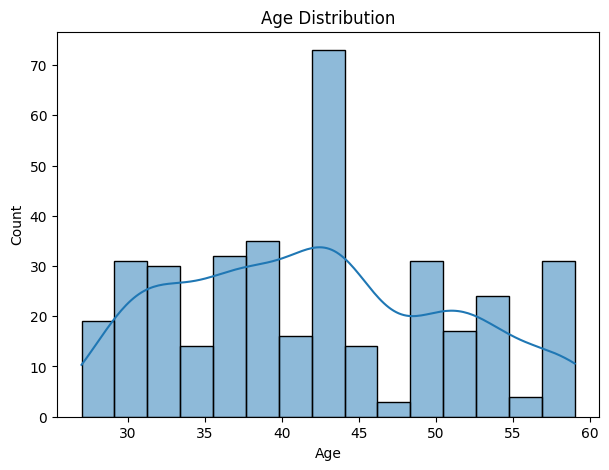

In [42]:
plt.figure(figsize=(7,5))

sns.histplot(
    data["Age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.show()

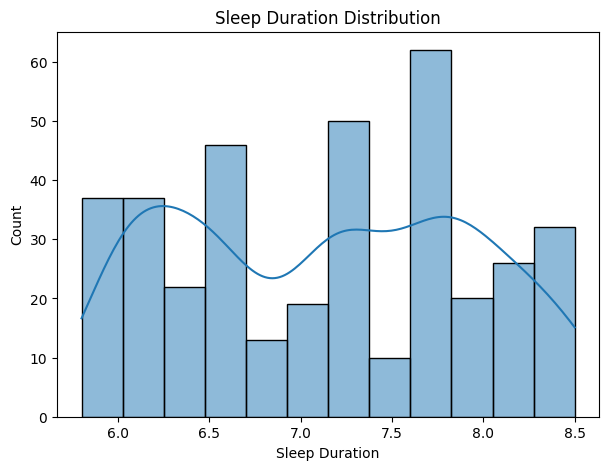

In [43]:
plt.figure(figsize=(7,5))

sns.histplot(
    data["Sleep Duration"],
    bins=12,
    kde=True
)

plt.title("Sleep Duration Distribution")
plt.show()

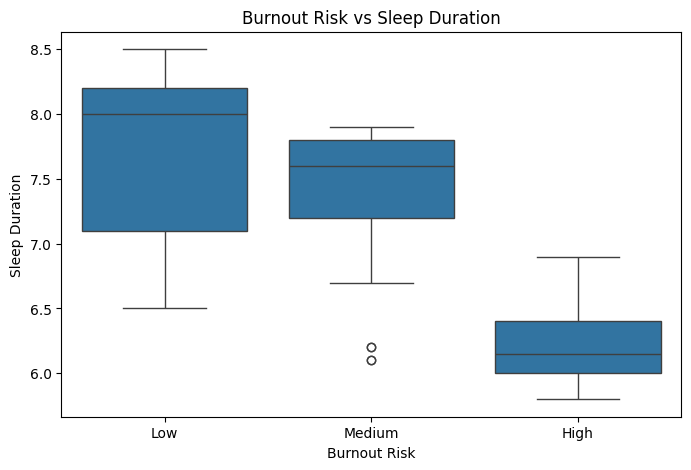

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Burnout Risk",
    y="Sleep Duration",
    data=data,
    order=["Low","Medium","High"]
)

plt.title("Burnout Risk vs Sleep Duration")
plt.show()

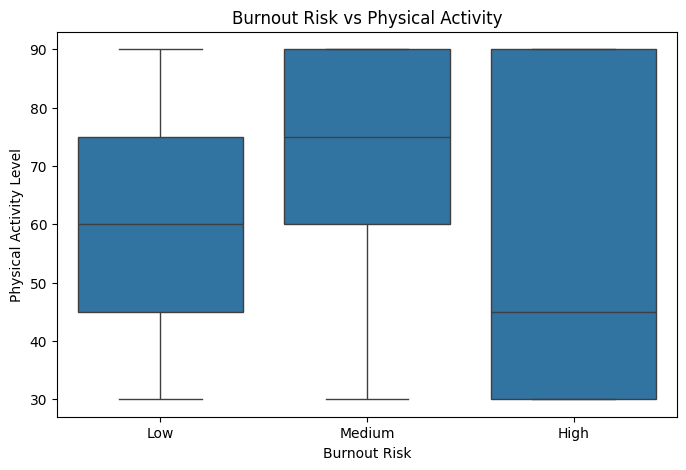

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Burnout Risk",
    y="Physical Activity Level",
    data=data,
    order=["Low","Medium","High"]
)

plt.title("Burnout Risk vs Physical Activity")
plt.show()

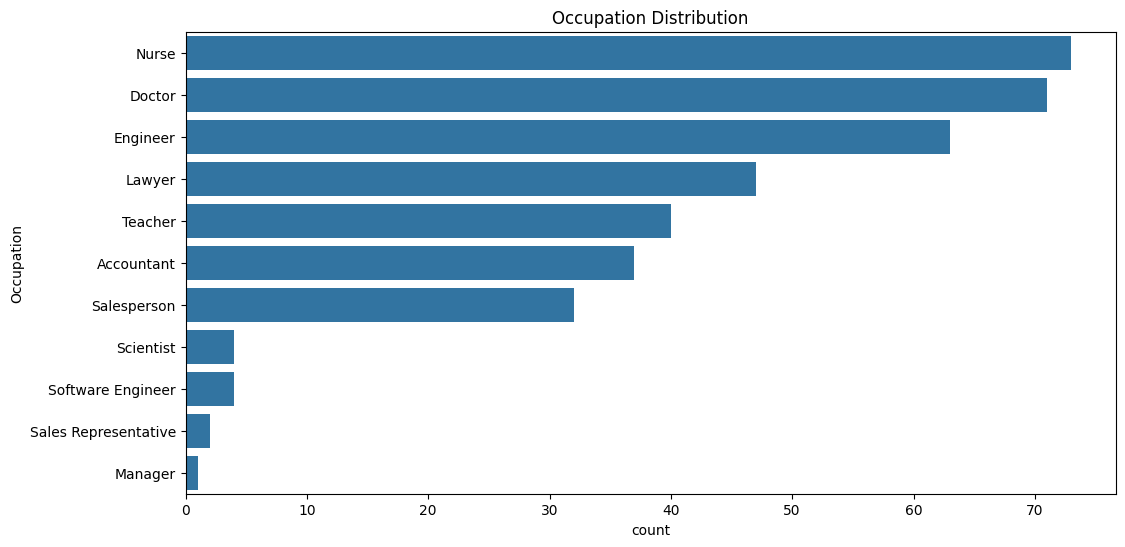

In [46]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="Occupation",
    data=data,
    order=data["Occupation"].value_counts().index
)

plt.title("Occupation Distribution")
plt.show()

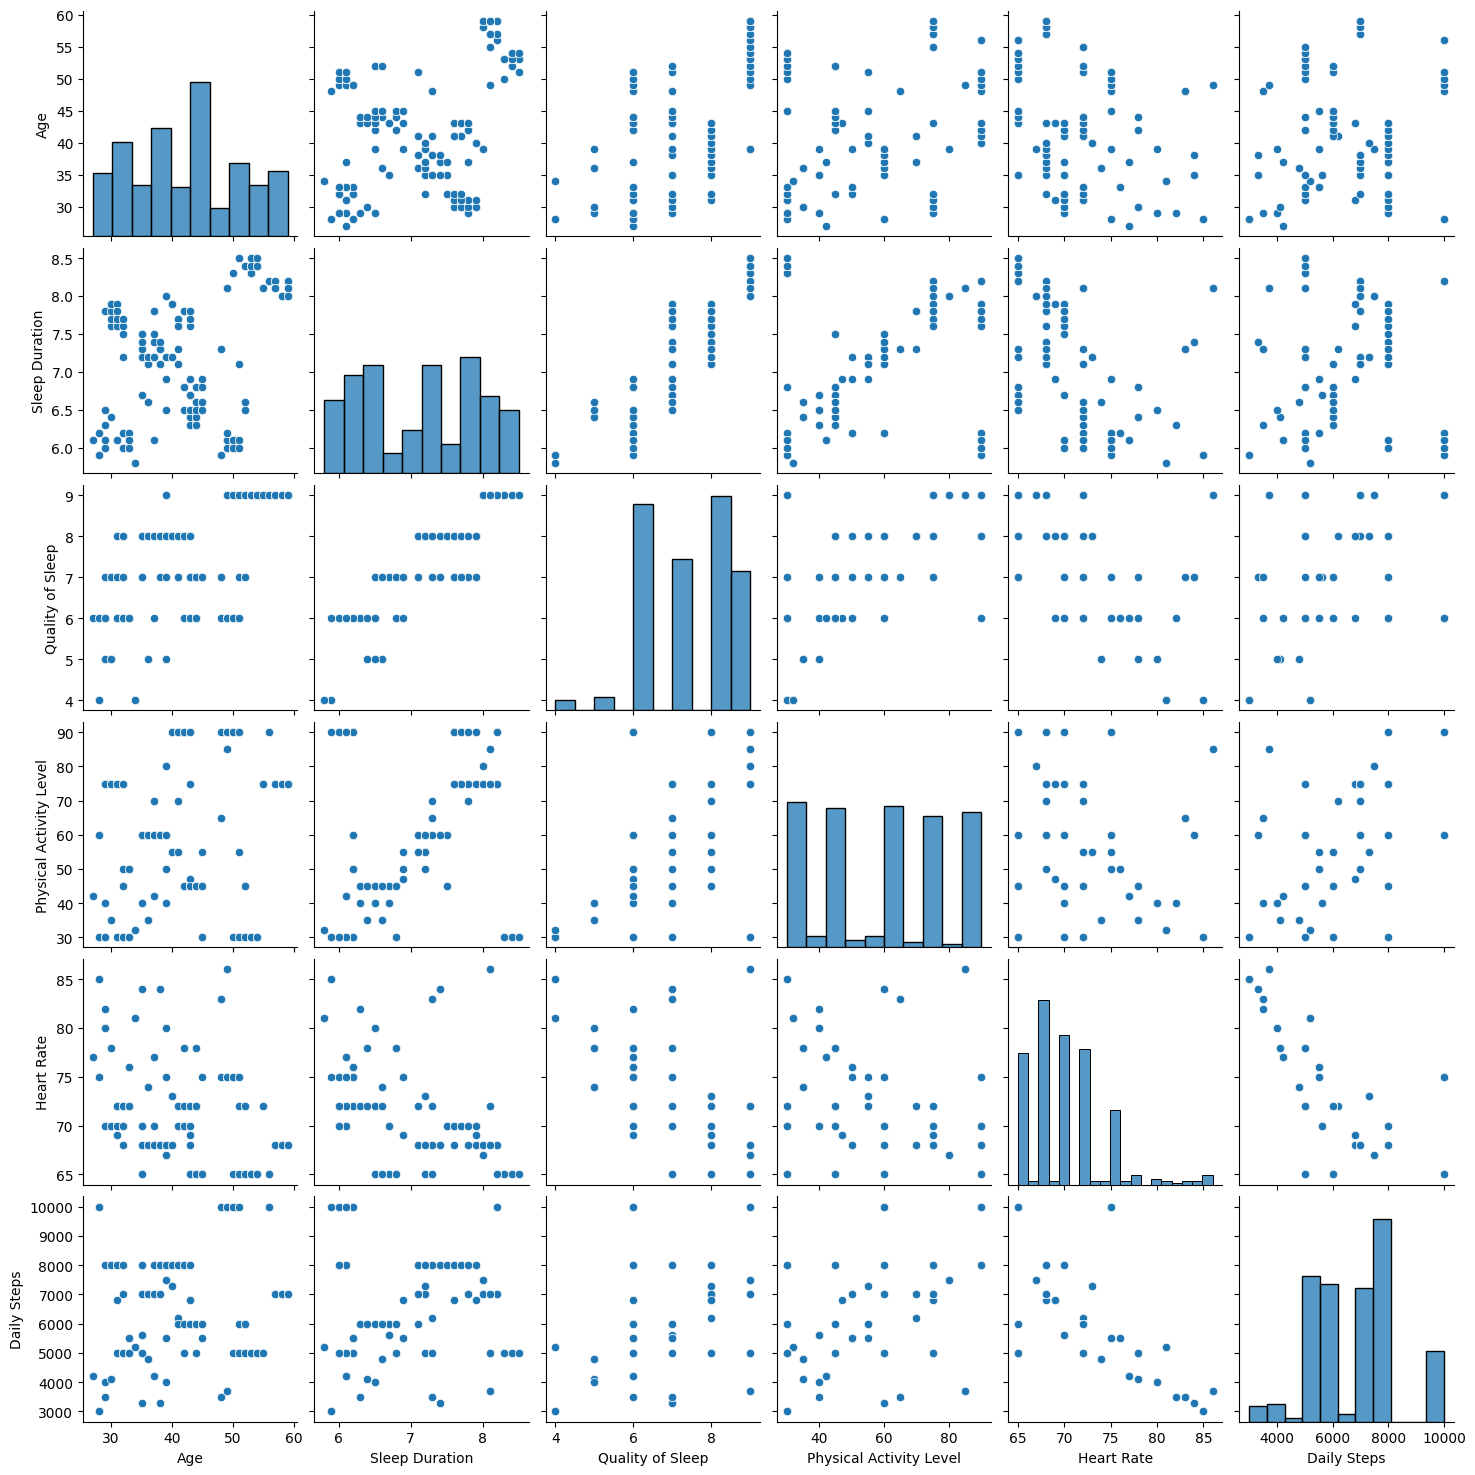

In [47]:
sns.pairplot(
    data[
        [
            "Age",
            "Sleep Duration",
            "Quality of Sleep",
            "Physical Activity Level",
            "Heart Rate",
            "Daily Steps"
        ]
    ]
)

plt.show()

# 7. Data Preprocessing

In [48]:
# Features (X)
X = data.drop(columns=[
    "Burnout Risk",
    "Stress Level",
    "Burnout Index",
    "Lifestyle Score",
    "Lifestyle Category"
])

# Target (y)
y = data["Burnout Risk"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (374, 13)
Target Shape: (374,)


In [49]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

categorical_columns = X.select_dtypes(include="object").columns

for column in categorical_columns:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders[column] = le

print("Categorical features encoded successfully!")

Categorical features encoded successfully!


In [50]:
target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print(target_encoder.classes_)

['High' 'Low' 'Medium']


In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (299, 13)
Testing Samples : (75, 13)


# 8. Machine Learning Model Development

In this section, multiple machine learning algorithms are trained and evaluated for predicting burnout risk. Their performances are compared using standard classification metrics to determine the most suitable model.

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import cross_val_score

print("Machine Learning Libraries Imported Successfully!")

Machine Learning Libraries Imported Successfully!


In [54]:
# Logistic Regression Model

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)

print(f"Logistic Regression Accuracy : {lr_accuracy:.4f}")

Logistic Regression Accuracy : 0.9600


In [55]:
print(classification_report(
    y_test,
    lr_predictions,
    target_names=target_encoder.classes_
))

              precision    recall  f1-score   support

        High       0.92      1.00      0.96        24
         Low       1.00      0.96      0.98        28
      Medium       0.95      0.91      0.93        23

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



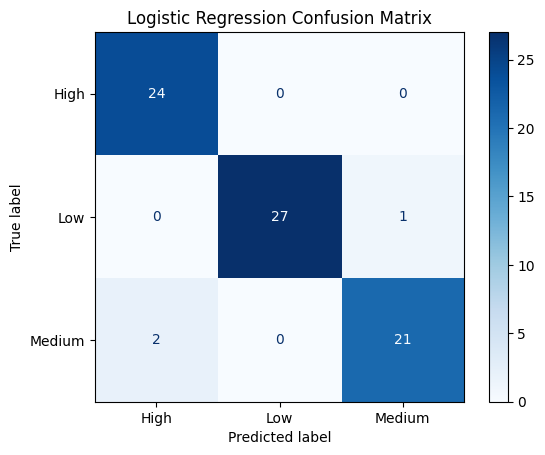

In [56]:
cm = confusion_matrix(y_test, lr_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [57]:
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5
)

print("Cross Validation Scores")

print(cv_scores)

print()

print("Average Accuracy :", cv_scores.mean())

Cross Validation Scores
[0.89333333 0.89333333 0.96       0.96       0.91891892]

Average Accuracy : 0.9251171171171171


In [58]:
results = {}

results["Logistic Regression"] = lr_accuracy

## 8.2 Decision Tree Classifier

In [59]:
# Decision Tree

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print(f"Decision Tree Accuracy : {dt_accuracy:.4f}")

Decision Tree Accuracy : 0.9733


In [60]:
print(classification_report(
    y_test,
    dt_predictions,
    target_names=target_encoder.classes_
))

              precision    recall  f1-score   support

        High       0.92      1.00      0.96        24
         Low       1.00      1.00      1.00        28
      Medium       1.00      0.91      0.95        23

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75



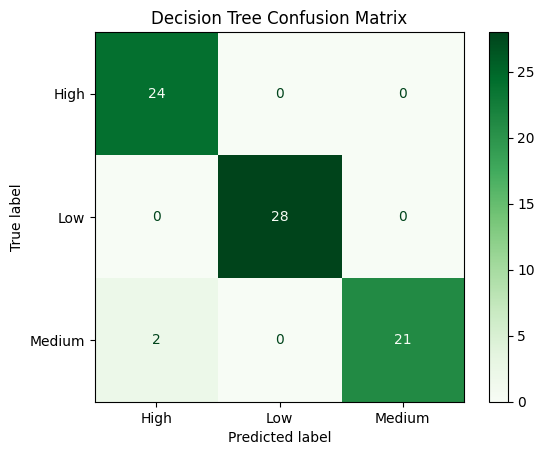

In [61]:
cm = confusion_matrix(y_test, dt_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [62]:
cv_scores_dt = cross_val_score(
    dt_model,
    X_scaled,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores_dt)

print()

print("Average Accuracy:", cv_scores_dt.mean())

Cross Validation Scores:
[0.85333333 0.88       0.94666667 0.96       0.83783784]

Average Accuracy: 0.8955675675675676


In [63]:
results["Decision Tree"] = dt_accuracy

## 8.3 Random Forest Classifier

In [64]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print(f"Random Forest Accuracy : {rf_accuracy:.4f}")

Random Forest Accuracy : 0.9467


In [65]:
print(classification_report(
    y_test,
    rf_predictions,
    target_names=target_encoder.classes_
))

              precision    recall  f1-score   support

        High       0.92      1.00      0.96        24
         Low       0.93      1.00      0.97        28
      Medium       1.00      0.83      0.90        23

    accuracy                           0.95        75
   macro avg       0.95      0.94      0.94        75
weighted avg       0.95      0.95      0.95        75



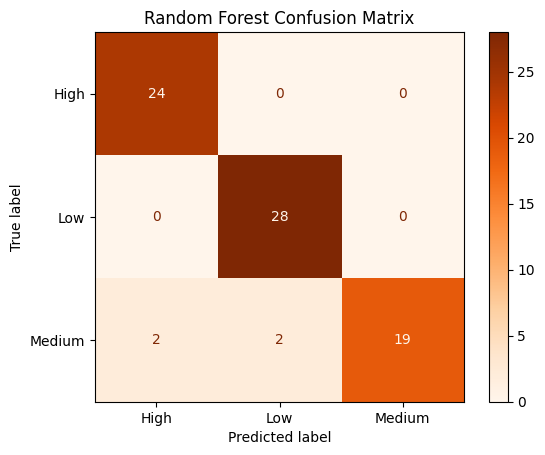

In [66]:
cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap="Oranges")

plt.title("Random Forest Confusion Matrix")

plt.show()

In [67]:
cv_scores_rf = cross_val_score(
    rf_model,
    X_scaled,
    y,
    cv=5
)

print("Cross Validation Scores:")
print(cv_scores_rf)

print()

print("Average Accuracy:", cv_scores_rf.mean())

Cross Validation Scores:
[0.86666667 0.90666667 0.96       1.         0.89189189]

Average Accuracy: 0.9250450450450451


In [68]:
results["Random Forest"] = rf_accuracy

In [69]:
results

{'Logistic Regression': 0.96,
 'Decision Tree': 0.9733333333333334,
 'Random Forest': 0.9466666666666667}

## 8.4 XGBoost Classifier

In [70]:
from xgboost import XGBClassifier

In [71]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_predictions)

print(f"XGBoost Accuracy : {xgb_accuracy:.4f}")

XGBoost Accuracy : 0.9733


In [72]:
print(classification_report(
    y_test,
    xgb_predictions,
    target_names=target_encoder.classes_
))

              precision    recall  f1-score   support

        High       0.92      1.00      0.96        24
         Low       1.00      1.00      1.00        28
      Medium       1.00      0.91      0.95        23

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75



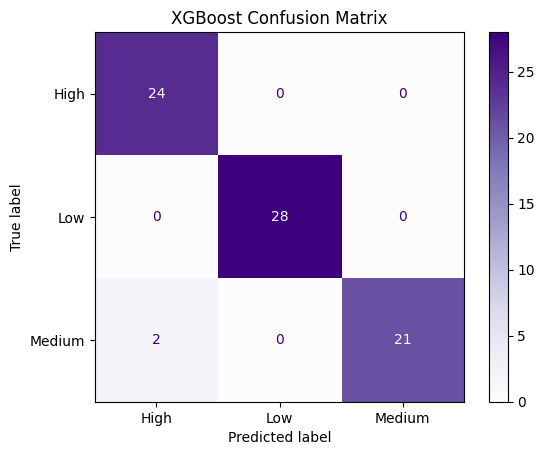

In [73]:
cm = confusion_matrix(y_test, xgb_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap="Purples")

plt.title("XGBoost Confusion Matrix")

plt.show()

In [74]:
cv_scores_xgb = cross_val_score(
    xgb_model,
    X_scaled,
    y,
    cv=5
)

print(cv_scores_xgb)
print(cv_scores_xgb.mean())

[0.86666667 0.90666667 0.96       0.94666667 0.94594595]
0.9251891891891892


In [75]:
results["XGBoost"] = xgb_accuracy

In [76]:
results_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
1,Decision Tree,0.973333
3,XGBoost,0.973333
0,Logistic Regression,0.960000
2,Random Forest,0.946667


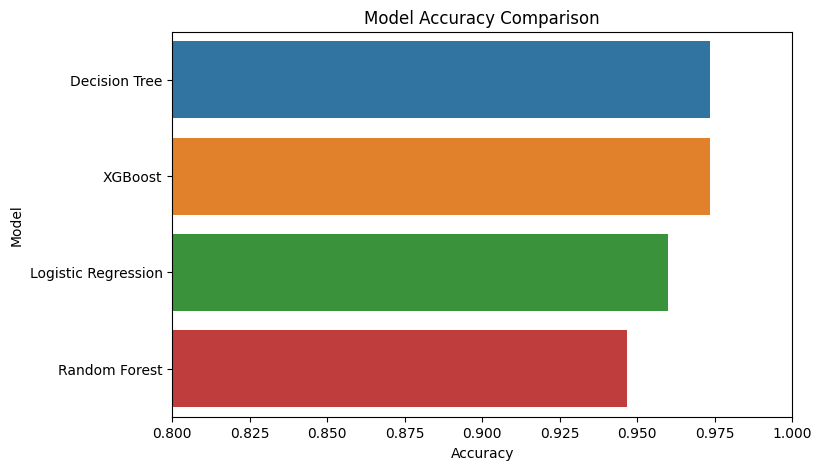

In [77]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.xlim(0.8, 1.0)

plt.show()

## 8.5 Neural Network (MLP Classifier)

In [78]:
from sklearn.neural_network import MLPClassifier

In [79]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(64,32),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42,
    early_stopping=True
)

mlp_model.fit(X_train, y_train)

mlp_predictions = mlp_model.predict(X_test)

mlp_accuracy = accuracy_score(y_test, mlp_predictions)

print(f"MLP Accuracy : {mlp_accuracy:.4f}")

MLP Accuracy : 0.8800


In [80]:
print(classification_report(
    y_test,
    mlp_predictions,
    target_names=target_encoder.classes_
))

              precision    recall  f1-score   support

        High       0.88      0.88      0.88        24
         Low       0.93      0.89      0.91        28
      Medium       0.83      0.87      0.85        23

    accuracy                           0.88        75
   macro avg       0.88      0.88      0.88        75
weighted avg       0.88      0.88      0.88        75



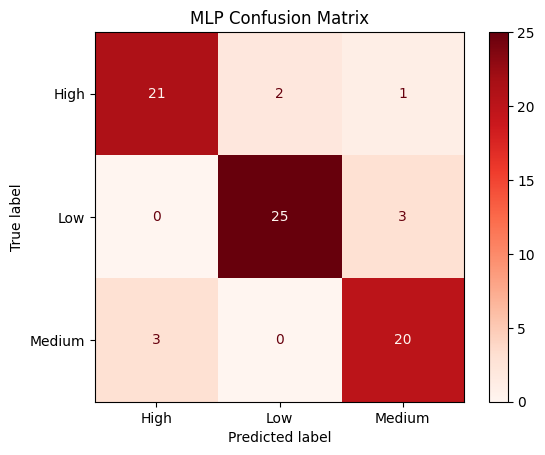

In [81]:
cm = confusion_matrix(y_test, mlp_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap="Reds")

plt.title("MLP Confusion Matrix")

plt.show()

In [82]:
cv_scores_mlp = cross_val_score(
    mlp_model,
    X_scaled,
    y,
    cv=5
)

print(cv_scores_mlp)

print(cv_scores_mlp.mean())

[0.82666667 0.90666667 0.93333333 0.92       0.44594595]
0.8065225225225225


In [83]:
results["Neural Network"] = mlp_accuracy

# 9. Unsupervised Learning

## K-Means Clustering

In [84]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [85]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

data["Cluster"] = clusters

In [86]:
data["Cluster"].value_counts()

Cluster
1    215
2     92
0     67
Name: count, dtype: int64

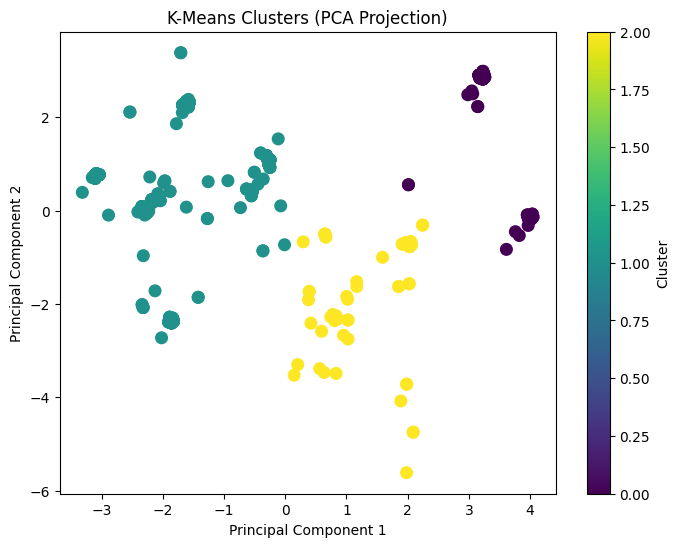

In [87]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=70
)

plt.title("K-Means Clusters (PCA Projection)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [88]:
cluster_summary = data.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP,Lifestyle Score,Burnout Index
Cluster,,,,,,,,,,,
0,53.805970,7.125373,7.567164,82.462687,5.417910,72.000000,8274.626866,139.970149,94.880597,88.839552,65.339552
1,38.683721,7.403721,7.683721,58.381395,5.102326,68.813953,6919.534884,123.474419,80.502326,83.073907,67.949349
2,41.902174,6.502174,6.260870,44.054348,6.021739,71.989130,5515.217391,132.108696,86.891304,67.614130,92.603261


In [89]:
import shap

In [92]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

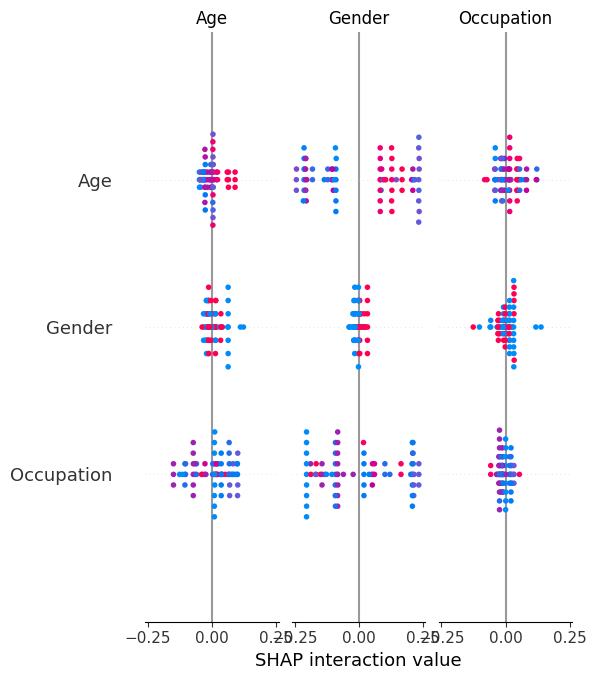

In [93]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

In [94]:
results_df = pd.DataFrame(
    results.items(),
    columns=["Model","Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
1,Decision Tree,0.973333
3,XGBoost,0.973333
0,Logistic Regression,0.960000
2,Random Forest,0.946667
4,Neural Network,0.880000


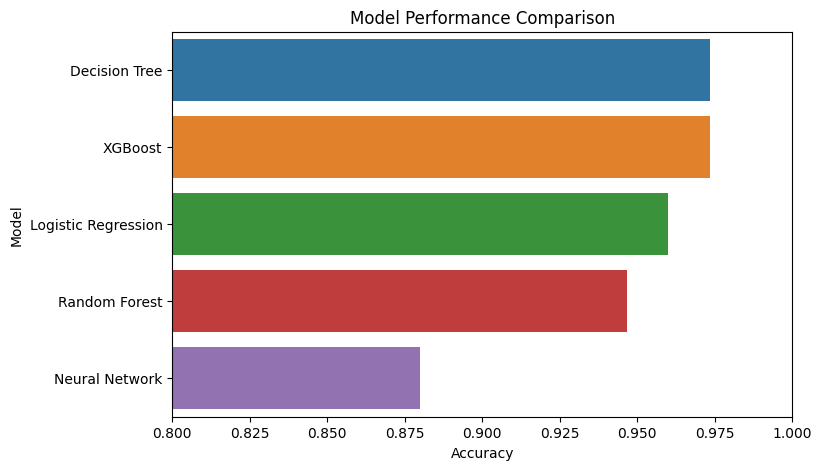

In [95]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    legend=False
)

plt.xlim(0.8,1.0)

plt.title("Model Performance Comparison")

plt.show()